In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [17]:
dataset_path = r"D:\DeepLearning\dataset-resized"

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print(train_data.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6,activation='softmax'))

c:\Users\Admin-THC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 711ms/step - accuracy: 0.2905 - loss: 1.6813 - val_accuracy: 0.3658 - val_loss: 1.5758
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 439ms/step - accuracy: 0.4106 - loss: 1.4460 - val_accuracy: 0.3897 - val_loss: 1.4850
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.4407 - loss: 1.3817 - val_accuracy: 0.4334 - val_loss: 1.4399
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 365ms/step - accuracy: 0.4916 - loss: 1.2805 - val_accuracy: 0.4414 - val_loss: 1.3712
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 370ms/step - accuracy: 0.5040 - loss: 1.2467 - val_accuracy: 0.4433 - val_loss: 1.3883
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 410ms/step - accuracy: 0.5455 - loss: 1.1902 - val_accuracy: 0.4911 - val_loss: 1.3568
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.5677 - loss: 1.1224 - val_accuracy: 0.4891 - val_loss: 1.3006
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 360ms/step - accuracy: 0.5939 - loss: 1.0401 - val_accu

In [11]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 384ms/step - accuracy: 0.6744 - loss: 0.8451 - val_accuracy: 0.4930 - val_loss: 1.3360
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 356ms/step - accuracy: 0.6966 - loss: 0.7829 - val_accuracy: 0.4930 - val_loss: 1.3679
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 417ms/step - accuracy: 0.7411 - loss: 0.6983 - val_accuracy: 0.5567 - val_loss: 1.3867
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 387ms/step - accuracy: 0.7609 - loss: 0.6499 - val_accuracy: 0.5328 - val_loss: 1.3513
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 302ms/step - accuracy: 0.7579 - loss: 0.6469 - val_accuracy: 0.5368 - val_loss: 1.5308
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.7935 - loss: 0.5488 - val_accuracy: 0.4930 - val_loss: 1.5892
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - accuracy: 0.7875 - loss: 0.5766 - val_accuracy: 0.5547 - val_loss: 1.5121
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.8108 - loss: 0.5106 - val_accu

In [13]:
model.save("waste_classifier.h5")

print("Model Saved Successfully")

Model Saved Successfully


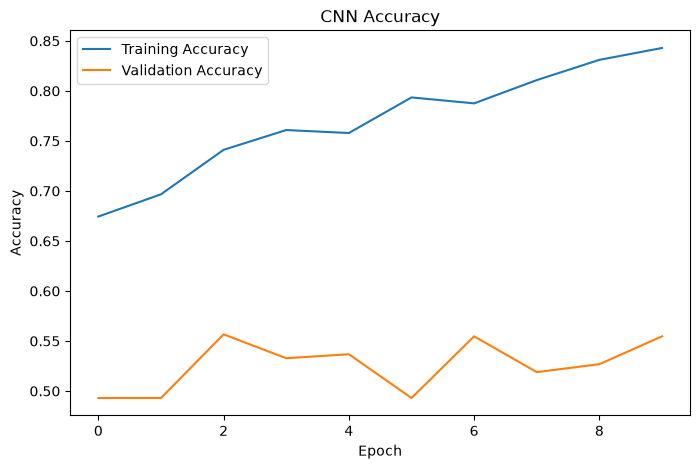

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.show()

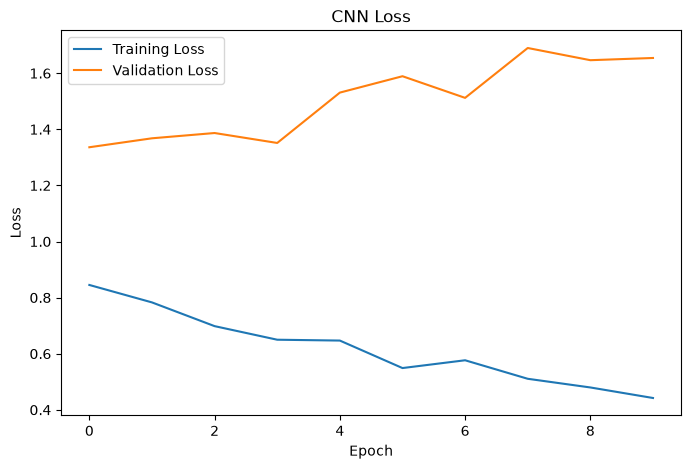

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.show()

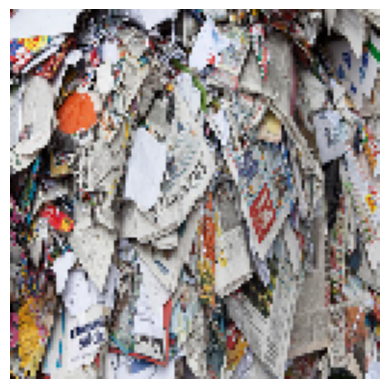

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Class : paper
Confidence : 98.66 %


In [20]:
classes = [
    'cardboard',
    'glass',
    'metal',
    'paper',
    'plastic',
    'trash'
]

img_path = r"D:\DeepLearning\CNN\trash.jpg"

img = image.load_img(img_path,target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array = img_array/255

prediction = model.predict(img_array)

index = np.argmax(prediction)

confidence = np.max(prediction)*100

print("Predicted Class :",classes[index])
print("Confidence :",round(confidence,2),"%")